# Icon Generation with Stable Diffusion + LoRA

This notebook fine-tunes Stable Diffusion 1.5 with LoRA on icon datasets for custom icon generation.

## Architecture
- **Base Model**: Stable Diffusion 1.5
- **Fine-tuning Method**: LoRA (Low-Rank Adaptation)
- **Training Target**: UNet attention layers only
- **Data**: Icon images + captions from LLaVA annotations

## 1. Setup & Imports

In [1]:
import os
import sys
import math
import logging
from pathlib import Path
from datetime import datetime

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from PIL import Image
from tqdm.auto import tqdm

from diffusers import (
    StableDiffusionPipeline,
    DDPMScheduler,
    AutoencoderKL,
    UNet2DConditionModel,
)
from diffusers.optimization import get_cosine_schedule_with_warmup
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent))
from src.dataset import IconDataset

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

print("✓ All imports successful")

/home/jiwon-hae/miniforge3/envs/icongen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jiwon-hae/miniforge3/envs/icongen/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()
WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.9.1+cpu with CUDA None (you have 2.10.0.dev20251114+cu130)
    Python  3.10.19 (you have 3.10.19)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
/home/jiwon-hae/mi

✓ All imports successful


## 2. Configuration

In [ ]:
# ============================================================================
# DATA CONFIGURATION
# ============================================================================
DATA_DIR = Path("../data")
IMG_DIR = DATA_DIR / "icons_256"
META_FILE = DATA_DIR / "icons_metadata.jsonl"

# ============================================================================
# MODEL CONFIGURATION
# ============================================================================
MODEL_ID = "runwayml/stable-diffusion-v1-5"
IMAGE_SIZE = 256

# ============================================================================
# LORA CONFIGURATION
# ============================================================================
LORA_RANK = 16  # Lower = fewer parameters, faster training
LORA_ALPHA = 16  # Scaling factor for LoRA updates

# ============================================================================
# TRAINING HYPERPARAMETERS
# ============================================================================
TRAIN_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4
EFFECTIVE_BATCH_SIZE = TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS

NUM_TRAIN_STEPS = 10_000
LEARNING_RATE = 1e-4
ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.999
ADAM_EPSILON = 1e-8
ADAM_WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
LR_WARMUP_STEPS = 500

# ============================================================================
# EARLY STOPPING & CHECKPOINTING
# ============================================================================
EARLY_STOPPING_PATIENCE = 10  # Stop if no improvement for N validation checks
MIN_DELTA = 0.001  # Minimum improvement to count as better
VAL_SPLIT = 0.05  # Use 5% of data for validation

# ============================================================================
# SAMPLE GENERATION DURING TRAINING - NEW
# ============================================================================
GENERATE_SAMPLES_EVERY = 20  # Generate sample images every N steps
NUM_INFERENCE_STEPS = 20  # Fewer steps = faster generation during training
GUIDANCE_SCALE = 7.5

# Fixed prompts to track progress
SAMPLE_PROMPTS = [
    "simple heart icon, flat design, red color",
    "shopping cart icon, minimalist, blue",
    "settings gear icon, clean lines, gray",
]

# ============================================================================
# SYSTEM CONFIGURATION
# ============================================================================
MIXED_PRECISION = "fp16"  # "fp16", "bf16", or "no"
SEED = 42
NUM_WORKERS = 4
USE_WANDB = False  # Set to True to enable W&B logging

# ============================================================================
# OUTPUT CONFIGURATION
# ============================================================================
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = Path(f"./outputs/icon_sd15_lora_{TIMESTAMP}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

SAMPLES_DIR = OUTPUT_DIR / "training_samples"  # NEW
SAMPLES_DIR.mkdir(exist_ok=True)

SAVE_STEPS = 500  # Regular checkpoint interval
VALIDATION_STEPS = 250  # Validation & best checkpoint check interval
LOGGING_STEPS = 50

# ============================================================================
# VALIDATION PROMPTS
# ============================================================================
VALIDATION_PROMPTS = [
    "cute flat-style avocado icon, minimalist, pastel colors, white background",
    "modern shopping cart icon, clean lines, blue gradient, 2D vector style",
    "heart icon with sparkles, kawaii style, pink and white colors",
    "coffee cup icon, simple design, brown tones, flat illustration",
]

# Print configuration
print(f"{'='*60}")
print(f"TRAINING CONFIGURATION")
print(f"{'='*60}")
print(f"Model: {MODEL_ID}")
print(f"Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"LoRA Rank: {LORA_RANK}")
print(f"Effective Batch Size: {EFFECTIVE_BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Training Steps: {NUM_TRAIN_STEPS:,}")
print(f"Mixed Precision: {MIXED_PRECISION}")
print(f"Validation Split: {VAL_SPLIT*100:.0f}%")
print(f"Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")
print(f"Sample Generation: Every {GENERATE_SAMPLES_EVERY} steps")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"{'='*60}")

## 3. Verify Data

In [3]:
# Check if data exists
if not IMG_DIR.exists():
    raise FileNotFoundError(f"Image directory not found: {IMG_DIR}")

if not META_FILE.exists():
    raise FileNotFoundError(f"Metadata file not found: {META_FILE}")

# Count images
num_images = len(list(IMG_DIR.glob("*.png")))
print(f"✓ Found {num_images:,} images in {IMG_DIR}")

# Count metadata entries
import json
num_entries = sum(1 for _ in open(META_FILE))
print(f"✓ Found {num_entries:,} metadata entries in {META_FILE}")

# Show sample metadata
with open(META_FILE) as f:
    sample = json.loads(f.readline())
    print(f"\nSample metadata:")
    print(f"  Image: {sample.get('image')}")
    print(f"  Caption: {sample.get('caption', '')[:100]}...")

✓ Found 5,865 images in ../data/icons_256
✓ Found 4,108 metadata entries in ../data/icons_metadata.jsonl

Sample metadata:
  Image: FroggoInLove_13_00000.png
  Caption: USER:  
Describe this icon in detail.
ASSISTANT: The image features a green cartoon character with a...


## 4. Load Pretrained Models

In [4]:
logger.info(f"Loading Stable Diffusion model: {MODEL_ID}")

# Load the full pipeline first (easier than loading components separately)
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if MIXED_PRECISION == "fp16" else torch.float32,
    safety_checker=None,  # Disable for training
)

# Extract components
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
vae = pipe.vae
unet = pipe.unet

# Create noise scheduler for training
noise_scheduler = DDPMScheduler.from_config(pipe.scheduler.config)

# Enable memory optimizations
if hasattr(pipe, "enable_xformers_memory_efficient_attention"):
    try:
        pipe.enable_xformers_memory_efficient_attention()
        logger.info("✓ xFormers memory efficient attention enabled")
    except Exception as e:
        logger.warning(f"Could not enable xFormers: {e}")

# Enable gradient checkpointing for UNet to save memory
unet.enable_gradient_checkpointing()

print(f"✓ Models loaded successfully")
print(f"  - Tokenizer: {tokenizer.__class__.__name__}")
print(f"  - Text Encoder: {text_encoder.__class__.__name__}")
print(f"  - VAE: {vae.__class__.__name__}")
print(f"  - UNet: {unet.__class__.__name__}")

2025-11-22 23:54:07,168 - __main__ - INFO - Loading Stable Diffusion model: runwayml/stable-diffusion-v1-5
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 11.07it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
2025-11-22 23:54:08,238 - __main__ - WARNING - Could not enable xFormers: No operator found for `memory_efficient_attention_forward` with inputs:
     query       

✓ Models loaded successfully
  - Tokenizer: CLIPTokenizer
  - Text Encoder: CLIPTextModel
  - VAE: AutoencoderKL
  - UNet: UNet2DConditionModel


## 5. Setup LoRA Layers

In [5]:
logger.info("Setting up LoRA using PEFT library")

# Configure LoRA using PEFT
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],  # Attention layers in UNet
)

# Apply LoRA to UNet
unet = get_peft_model(unet, lora_config)

# Print trainable parameters
unet.print_trainable_parameters()

# Count parameters
total_params = sum(p.numel() for p in unet.parameters())
lora_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)
trainable_ratio = (lora_params / total_params) * 100

print(f"\n✓ LoRA setup complete")
print(f"  - Total UNet parameters: {total_params:,}")
print(f"  - LoRA trainable parameters: {lora_params:,}")
print(f"  - Trainable ratio: {trainable_ratio:.2f}%")
print(f"  - LoRA rank: {LORA_RANK}")

2025-11-22 23:54:08,262 - __main__ - INFO - Setting up LoRA using PEFT library


trainable params: 3,188,736 || all params: 862,709,700 || trainable%: 0.3696

✓ LoRA setup complete
  - Total UNet parameters: 862,709,700
  - LoRA trainable parameters: 3,188,736
  - Trainable ratio: 0.37%
  - LoRA rank: 16


## 6. Create Dataset & DataLoader

In [ ]:
logger.info("Creating dataset")

# Create full dataset
full_dataset = IconDataset(
    meta_path=META_FILE,
    img_dir=IMG_DIR,
    tokenizer=tokenizer,
    size=IMAGE_SIZE,
)

# Split into train and validation - IMPROVED
from torch.utils.data import random_split

val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Create dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# Calculate training statistics
num_update_steps_per_epoch = math.ceil(len(train_dataloader) / GRADIENT_ACCUMULATION_STEPS)
num_train_epochs = math.ceil(NUM_TRAIN_STEPS / num_update_steps_per_epoch)

print(f"✓ Dataset created")
print(f"  - Total samples: {len(full_dataset):,}")
print(f"  - Train samples: {len(train_dataset):,}")
print(f"  - Val samples: {len(val_dataset):,}")
print(f"  - Batches per epoch: {len(train_dataloader):,}")
print(f"  - Updates per epoch: {num_update_steps_per_epoch:,}")
print(f"  - Estimated epochs: {num_train_epochs}")

## 7. Setup Optimizer & Scheduler

In [7]:
# Create optimizer - only train LoRA parameters
trainable_params = [p for p in unet.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LEARNING_RATE,
    betas=(ADAM_BETA1, ADAM_BETA2),
    eps=ADAM_EPSILON,
    weight_decay=ADAM_WEIGHT_DECAY,
)

# Learning rate scheduler with warmup
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=LR_WARMUP_STEPS,
    num_training_steps=NUM_TRAIN_STEPS,
)

print(f"✓ Optimizer & scheduler configured")
print(f"  - Optimizer: AdamW")
print(f"  - Trainable parameters: {len(trainable_params):,}")
print(f"  - LR: {LEARNING_RATE}")
print(f"  - Warmup steps: {LR_WARMUP_STEPS}")
print(f"  - Scheduler: Cosine with warmup")

✓ Optimizer & scheduler configured
  - Optimizer: AdamW
  - Trainable parameters: 256
  - LR: 0.0001
  - Warmup steps: 500
  - Scheduler: Cosine with warmup


## 8. Initialize Logging (Optional)

In [ ]:
if USE_WANDB:
    wandb.init(
        project="icon-diffusion",
        name=f"sd15_lora_{TIMESTAMP}",
        config={
            "model": MODEL_ID,
            "lora_rank": LORA_RANK,
            "batch_size": EFFECTIVE_BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "num_steps": NUM_TRAIN_STEPS,
            "image_size": IMAGE_SIZE,
        }
    )
    print("✓ W&B logging initialized")
else:
    print("ℹ W&B logging disabled")


# ============================================================================
# VALIDATION & CHECKPOINT FUNCTIONS
# ============================================================================

def validate(unet, vae, text_encoder, val_dataloader, noise_scheduler, device, max_batches=None):
    """
    Run validation and compute average loss.
    
    Args:
        max_batches: If set, only validate on first N batches (for speed)
    """
    unet.eval()
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for i, batch in enumerate(val_dataloader):
            if max_batches and i >= max_batches:
                break
                
            # Move batch to device
            pixel_values = batch["pixel_values"].to(device, dtype=torch.float16)
            input_ids = batch["input_ids"].to(device)
            
            # Encode images to latent space
            latents = vae.encode(pixel_values * 2 - 1).latent_dist.sample()
            latents = latents * vae.config.scaling_factor
            
            # Sample noise
            noise = torch.randn_like(latents)
            
            # Sample timesteps
            timesteps = torch.randint(
                0,
                noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],),
                device=device,
                dtype=torch.long,
            )
            
            # Add noise
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            
            # Get text embeddings
            encoder_hidden_states = text_encoder(input_ids)[0]
            
            # Predict noise
            model_pred = unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
            ).sample
            
            # Compute loss
            loss = F.mse_loss(model_pred, noise, reduction="mean")
            total_loss += loss.item()
            num_batches += 1
    
    unet.train()
    avg_loss = total_loss / num_batches if num_batches > 0 else float('inf')
    return avg_loss


def save_checkpoint(unet, path, is_best=False):
    """Save LoRA checkpoint."""
    path.mkdir(exist_ok=True, parents=True)
    unet.save_pretrained(path)
    
    # Mark if this is the best checkpoint
    if is_best:
        best_marker = path.parent / "BEST_CHECKPOINT.txt"
        with open(best_marker, 'w') as f:
            f.write(f"{path.name}\n")
    
    return path


# ============================================================================
# SAMPLE GENERATION FUNCTION - NEW
# ============================================================================

@torch.no_grad()
def generate_samples(unet, vae, text_encoder, tokenizer, noise_scheduler, prompts, step, device):
    """
    Generate sample images during training to visualize progress.
    Returns a grid image combining all samples.
    """
    from diffusers import DDIMScheduler
    import matplotlib.pyplot as plt
    from IPython.display import display
    
    unet.eval()
    
    # Use DDIM for faster sampling during training
    ddim_scheduler = DDIMScheduler.from_config(noise_scheduler.config)
    
    generated_images = []
    
    for prompt in prompts:
        # Encode prompt
        text_input = tokenizer(
            prompt,
            padding="max_length",
            max_length=tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        text_embeddings = text_encoder(text_input.input_ids.to(device))[0]
        
        # Unconditional embeddings for classifier-free guidance
        uncond_input = tokenizer(
            "",
            padding="max_length",
            max_length=tokenizer.model_max_length,
            return_tensors="pt",
        )
        uncond_embeddings = text_encoder(uncond_input.input_ids.to(device))[0]
        
        # Concatenate for classifier-free guidance
        text_embeddings = torch.cat([uncond_embeddings, text_embeddings])
        
        # Random latents
        latents = torch.randn(
            (1, 4, IMAGE_SIZE // 8, IMAGE_SIZE // 8),
            device=device,
            dtype=torch.float16,
        )
        
        # Set timesteps
        ddim_scheduler.set_timesteps(NUM_INFERENCE_STEPS)
        latents = latents * ddim_scheduler.init_noise_sigma
        
        # Denoising loop
        for t in ddim_scheduler.timesteps:
            # Expand latents for classifier-free guidance
            latent_model_input = torch.cat([latents] * 2)
            latent_model_input = ddim_scheduler.scale_model_input(latent_model_input, t)
            
            # Predict noise
            noise_pred = unet(
                latent_model_input,
                t,
                encoder_hidden_states=text_embeddings,
            ).sample
            
            # Classifier-free guidance
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + GUIDANCE_SCALE * (noise_pred_text - noise_pred_uncond)
            
            # Compute previous latents
            latents = ddim_scheduler.step(noise_pred, t, latents).prev_sample
        
        # Decode latents to image
        latents = latents / vae.config.scaling_factor
        image = vae.decode(latents).sample
        
        # Convert to PIL
        image = (image / 2 + 0.5).clamp(0, 1)
        image = image.cpu().permute(0, 2, 3, 1).float().numpy()[0]
        image = (image * 255).round().astype("uint8")
        image = Image.fromarray(image)
        
        generated_images.append(image)
    
    unet.train()
    
    # Create a grid visualization
    n_images = len(generated_images)
    fig, axes = plt.subplots(1, n_images, figsize=(n_images * 3, 3))
    if n_images == 1:
        axes = [axes]
    
    for idx, (img, prompt) in enumerate(zip(generated_images, prompts)):
        axes[idx].imshow(img)
        axes[idx].set_title(f"Step {step}\n{prompt[:30]}...", fontsize=8)
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    # Save the grid
    grid_path = SAMPLES_DIR / f"samples_step_{step:05d}.png"
    plt.savefig(grid_path, dpi=100, bbox_inches='tight')
    
    # Display in notebook
    display(fig)
    plt.close()
    
    return grid_path, generated_images


class EarlyStoppingTracker:
    """Track validation loss and determine when to stop."""
    
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_step = 0
        
    def check(self, current_loss, step):
        """
        Returns: (should_save, should_stop)
        """
        if current_loss < self.best_loss - self.min_delta:
            # Improvement!
            improvement = self.best_loss - current_loss
            self.best_loss = current_loss
            self.best_step = step
            self.counter = 0
            print(f"💾 Validation loss improved by {improvement:.4f}! New best: {current_loss:.4f}")
            return True, False  # Save checkpoint, don't stop
        else:
            # No improvement
            self.counter += 1
            print(f"✗ No improvement ({self.counter}/{self.patience}) - Current: {current_loss:.4f}, Best: {self.best_loss:.4f} (step {self.best_step})")
            
            if self.counter >= self.patience:
                print(f"\n⚠️  Early stopping triggered! No improvement for {self.patience} validation checks.")
                return False, True  # Don't save, stop training
            
            return False, False  # Don't save, continue training

print("✓ Validation and checkpoint functions defined")
print(f"  - Validation: Runs every {VALIDATION_STEPS} steps")
print(f"  - Sample generation: Every {GENERATE_SAMPLES_EVERY} steps")
print(f"  - Early stopping: {EARLY_STOPPING_PATIENCE} checks without improvement")
print(f"  - Min delta: {MIN_DELTA}")

## 9. Training Loop

In [ ]:
logger.info("Starting training")
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move models to device
unet.to(device)
vae.to(device)
text_encoder.to(device)

# Freeze VAE and text encoder
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
# UNet LoRA layers are already set to trainable by PEFT

# Training state
global_step = 0
running_loss = 0.0

# Initialize early stopping tracker
early_stopping_tracker = EarlyStoppingTracker(
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=MIN_DELTA
)

# Progress bar
progress_bar = tqdm(
    range(NUM_TRAIN_STEPS),
    desc="Training",
    dynamic_ncols=True,
)

# Training loop
for epoch in range(num_train_epochs):
    logger.info(f"Epoch {epoch + 1}/{num_train_epochs}")
    
    for step, batch in enumerate(train_dataloader):
        if global_step >= NUM_TRAIN_STEPS:
            break

        with torch.no_grad():
            # Move batch to device
            pixel_values = batch["pixel_values"].to(device, dtype=torch.float16)
            input_ids = batch["input_ids"].to(device)
            
            # Encode images to latent space
            # VAE expects input in [-1, 1], our images are in [0, 1]
            latents = vae.encode(pixel_values * 2 - 1).latent_dist.sample()
            latents = latents * vae.config.scaling_factor  # 0.18215 for SD1.5

            # Sample noise to add to latents
            noise = torch.randn_like(latents)
            
            # Sample random timesteps
            timesteps = torch.randint(
                0,
                noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],),
                device=device,
                dtype=torch.long,
            )
            
            # Add noise to latents according to timestep
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            # Get text embeddings
            encoder_hidden_states = text_encoder(input_ids)[0]

        # Predict the noise residual
        model_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=encoder_hidden_states,
        ).sample

        # Compute loss
        loss = F.mse_loss(model_pred, noise, reduction="mean")

        # Scale loss for gradient accumulation
        loss = loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()

        running_loss += loss.item()

        # Update weights every N steps
        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(
                [p for p in unet.parameters() if p.requires_grad],
                MAX_GRAD_NORM
            )
            
            # Optimizer step
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            
            global_step += 1
            progress_bar.update(1)
            
            # Calculate actual loss (undo accumulation scaling)
            actual_loss = running_loss * GRADIENT_ACCUMULATION_STEPS
            running_loss = 0.0
            
            # Update progress bar
            progress_bar.set_postfix({
                "loss": f"{actual_loss:.4f}",
                "lr": f"{lr_scheduler.get_last_lr()[0]:.2e}",
                "best_val": f"{early_stopping_tracker.best_loss:.4f}" if early_stopping_tracker.best_loss != float('inf') else "N/A"
            })

            # Logging
            if global_step % LOGGING_STEPS == 0:
                logger.info(
                    f"Step {global_step}/{NUM_TRAIN_STEPS} | "
                    f"Loss: {actual_loss:.4f} | "
                    f"LR: {lr_scheduler.get_last_lr()[0]:.2e}"
                )
                
                if USE_WANDB:
                    import wandb
                    wandb.log({
                        "train_loss": actual_loss,
                        "learning_rate": lr_scheduler.get_last_lr()[0],
                        "step": global_step,
                    })

            # Generate sample images - NEW
            if global_step % GENERATE_SAMPLES_EVERY == 0:
                logger.info(f"Generating sample images at step {global_step}...")
                try:
                    grid_path, images = generate_samples(
                        unet, vae, text_encoder, tokenizer,
                        noise_scheduler, SAMPLE_PROMPTS, global_step, device
                    )
                    logger.info(f"✓ Samples saved: {grid_path}")
                    
                    if USE_WANDB:
                        import wandb
                        wandb.log({
                            "samples": [wandb.Image(img, caption=prompt) 
                                       for img, prompt in zip(images, SAMPLE_PROMPTS)],
                            "step": global_step,
                        })
                except Exception as e:
                    logger.warning(f"Failed to generate samples: {e}")

            # Validation & Early Stopping
            if global_step % VALIDATION_STEPS == 0:
                logger.info(f"Running validation at step {global_step}...")
                val_loss = validate(
                    unet, vae, text_encoder, val_dataloader,
                    noise_scheduler, device, max_batches=20  # Only use 20 batches for speed
                )
                logger.info(f"Validation loss: {val_loss:.4f}")
                
                if USE_WANDB:
                    import wandb
                    wandb.log({
                        "val_loss": val_loss,
                        "step": global_step,
                    })
                
                # Check if we should save or stop
                should_save, should_stop = early_stopping_tracker.check(val_loss, global_step)
                
                if should_save:
                    # Save best checkpoint
                    best_path = CHECKPOINT_DIR / f"best_step_{global_step}"
                    save_checkpoint(unet, best_path, is_best=True)
                    logger.info(f"✓ Best checkpoint saved: {best_path}")
                
                if should_stop:
                    logger.info(f"Early stopping at step {global_step}")
                    logger.info(f"Best validation loss: {early_stopping_tracker.best_loss:.4f} at step {early_stopping_tracker.best_step}")
                    break

            # Save regular checkpoint
            if global_step % SAVE_STEPS == 0:
                checkpoint_path = CHECKPOINT_DIR / f"step_{global_step}"
                save_checkpoint(unet, checkpoint_path, is_best=False)
                logger.info(f"✓ Checkpoint saved: {checkpoint_path}")

        if global_step >= NUM_TRAIN_STEPS:
            break
    
    # Check if early stopping was triggered
    if early_stopping_tracker.counter >= early_stopping_tracker.patience:
        break

progress_bar.close()
logger.info("Training complete!")
logger.info(f"Best validation loss: {early_stopping_tracker.best_loss:.4f} at step {early_stopping_tracker.best_step}")
logger.info(f"Sample images saved to: {SAMPLES_DIR}")

## 10. Save Final Model

In [10]:
# Save final LoRA weights using PEFT
final_path = OUTPUT_DIR / "final_lora"
final_path.mkdir(exist_ok=True)

# Save using PEFT format
unet.save_pretrained(final_path)

logger.info(f"✓ Final model saved to: {final_path}")
print(f"\n{'='*60}")
print(f"TRAINING COMPLETE!")
print(f"{'='*60}")
print(f"Final LoRA weights: {final_path}")
print(f"Checkpoints: {CHECKPOINT_DIR}")
print(f"{'='*60}")

2025-11-23 02:04:33,934 - __main__ - INFO - ✓ Final model saved to: outputs/icon_sd15_lora_20251122_235407/final_lora



TRAINING COMPLETE!
Final LoRA weights: outputs/icon_sd15_lora_20251122_235407/final_lora
Checkpoints: outputs/icon_sd15_lora_20251122_235407/checkpoints


## 11. Test Inference

Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  7.69it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


✓ Inference pipeline ready with trained LoRA weights

Generating validation images...

[1/4] cute flat-style avocado icon, minimalist, pastel colors, whi...


100%|██████████| 30/30 [00:01<00:00, 22.01it/s]


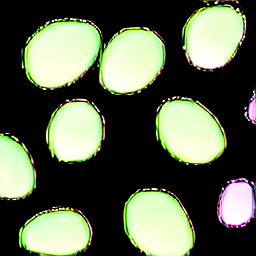

[2/4] modern shopping cart icon, clean lines, blue gradient, 2D ve...


100%|██████████| 30/30 [00:01<00:00, 23.29it/s]


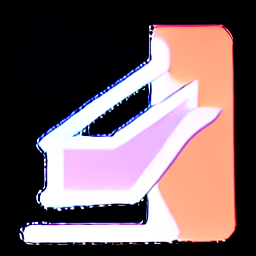

[3/4] heart icon with sparkles, kawaii style, pink and white color...


100%|██████████| 30/30 [00:01<00:00, 23.22it/s]


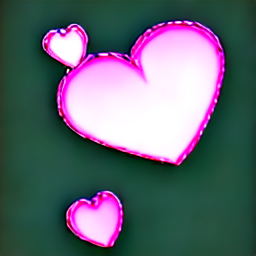

[4/4] coffee cup icon, simple design, brown tones, flat illustrati...


100%|██████████| 30/30 [00:01<00:00, 23.32it/s]


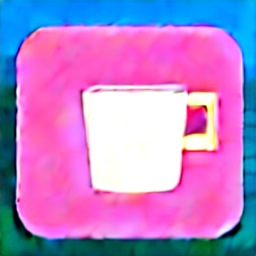


✓ Validation images saved to: outputs/icon_sd15_lora_20251122_235407/validation_images


In [11]:
from peft import PeftModel

# Reload base pipeline for inference
inference_pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
).to("cuda")

# Load LoRA weights into UNet using PEFT
inference_pipe.unet = PeftModel.from_pretrained(
    inference_pipe.unet,
    final_path,
)

print("✓ Inference pipeline ready with trained LoRA weights")
print(f"\nGenerating validation images...\n")

# Generate test images
validation_dir = OUTPUT_DIR / "validation_images"
validation_dir.mkdir(exist_ok=True)

for i, prompt in enumerate(VALIDATION_PROMPTS):
    print(f"[{i+1}/{len(VALIDATION_PROMPTS)}] {prompt[:60]}...")
    
    image = inference_pipe(
        prompt,
        num_inference_steps=30,
        guidance_scale=7.5,
        height=IMAGE_SIZE,
        width=IMAGE_SIZE,
    ).images[0]
    
    # Save image
    save_path = validation_dir / f"validation_{i}.png"
    image.save(save_path)
    
    # Display in notebook
    display(image)
    
    if USE_WANDB:
        import wandb
        wandb.log({f"validation/{i}": wandb.Image(image, caption=prompt)})

print(f"\n✓ Validation images saved to: {validation_dir}")

## 12. Cleanup & Summary

In [12]:
# Clean up GPU memory
del unet, vae, text_encoder, inference_pipe
torch.cuda.empty_cache()

# Close W&B
if USE_WANDB:
    import wandb
    wandb.finish()

print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Model: {MODEL_ID}")
print(f"Training Steps: {NUM_TRAIN_STEPS:,}")
print(f"LoRA Rank: {LORA_RANK}")
print(f"Dataset Size: {len(dataset):,} samples")
print(f"\nOutput Directory: {OUTPUT_DIR}")
print(f"  - Final LoRA: {final_path}")
print(f"  - Checkpoints: {CHECKPOINT_DIR}")
print(f"  - Validation: {validation_dir}")
print("="*60)
print("\n✓ All done! Your custom icon generator is ready.")
print("\nTo use the trained model:")
print("  1. Load base model: StableDiffusionPipeline.from_pretrained(...)")
print(f"  2. Load LoRA: PeftModel.from_pretrained(pipe.unet, '{final_path}')")
print("  3. Generate: pipe(prompt, ...)")


TRAINING SUMMARY
Model: runwayml/stable-diffusion-v1-5
Training Steps: 10,000
LoRA Rank: 16
Dataset Size: 4,108 samples

Output Directory: outputs/icon_sd15_lora_20251122_235407
  - Final LoRA: outputs/icon_sd15_lora_20251122_235407/final_lora
  - Checkpoints: outputs/icon_sd15_lora_20251122_235407/checkpoints
  - Validation: outputs/icon_sd15_lora_20251122_235407/validation_images

✓ All done! Your custom icon generator is ready.

To use the trained model:
  1. Load base model: StableDiffusionPipeline.from_pretrained(...)
  2. Load LoRA: PeftModel.from_pretrained(pipe.unet, 'outputs/icon_sd15_lora_20251122_235407/final_lora')
  3. Generate: pipe(prompt, ...)
